In [1]:
# Notebook 1: Dataset → DataFrame → EDA → Tokenization.
# Notebook 2: TF-IDF + Logistic Regression from scratch.
# Notebook 3: DistilBERT embeddings and inference and Transformer Embeddings and DistilBERT.
# Notebook 4: Fine-tuning a Transformer classifier.
# Notebook 5: Explainability (SHAP, LIME, Integrated Gradients).
# Notebook 6: Build the Streamlit "Text Classifier Visualizer" app.

In [2]:
from datasets import load_dataset

# Load the Emotion dataset
dataset = load_dataset("emotion")

dataset

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\vinna\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sat Jun 13 12:36:46 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [3]:
print(dataset)

print("\nFirst training example:")
print(dataset["train"][0])

print("\nDataset features:")
print(dataset["train"].features)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

First training example:
{'text': 'i didnt feel humiliated', 'label': 0}

Dataset features:
{'text': Value(dtype='string', id=None), 'label': ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'], id=None)}


In [4]:
import pandas as pd

train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


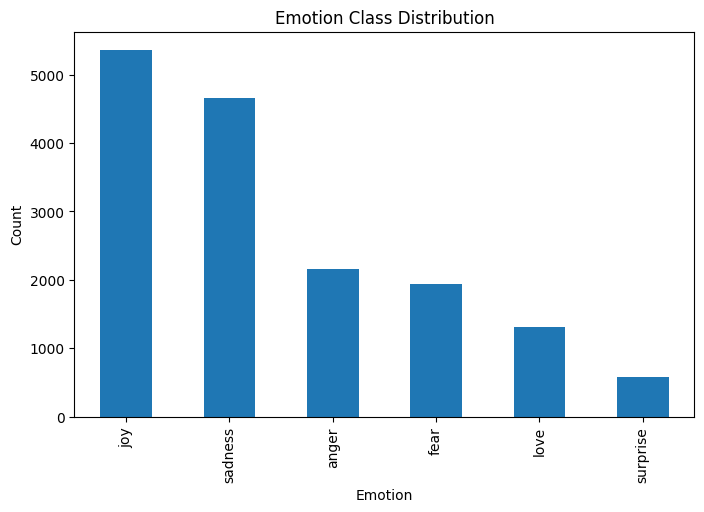

In [5]:
import matplotlib.pyplot as plt

# Get label names
label_names = dataset["train"].features["label"].names

# Convert label IDs to label names
train_df["label_name"] = train_df["label"].apply(lambda x: label_names[x])

# Plot class distribution
train_df["label_name"].value_counts().plot(
    kind="bar", title="Emotion Class Distribution", figsize=(8, 5)
)

plt.xlabel("Emotion")
plt.ylabel("Count")
plt.show()

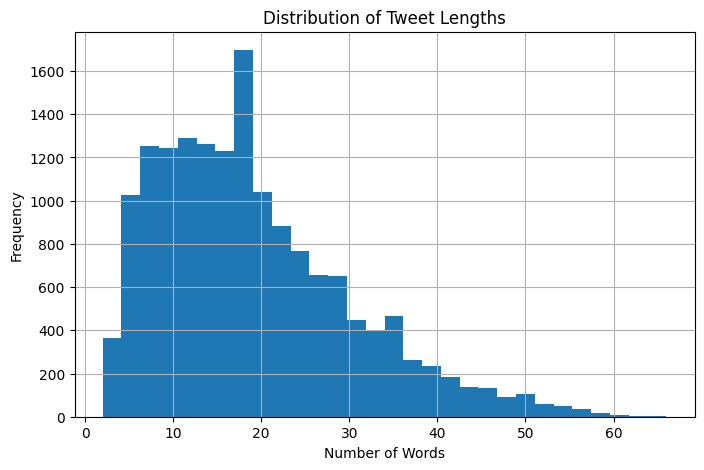

In [6]:
# Count words in each text
train_df["tweet_length"] = train_df["text"].str.split().apply(len)

# Plot histogram
train_df["tweet_length"].hist(bins=30, figsize=(8, 5))

plt.title("Distribution of Tweet Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

In [7]:
text = "I hated the plot, but the acting was phenomenal!"

print("Original Text:")
print(text)

print("\nCharacter Tokenization:")
print(list(text))

Original Text:
I hated the plot, but the acting was phenomenal!

Character Tokenization:
['I', ' ', 'h', 'a', 't', 'e', 'd', ' ', 't', 'h', 'e', ' ', 'p', 'l', 'o', 't', ',', ' ', 'b', 'u', 't', ' ', 't', 'h', 'e', ' ', 'a', 'c', 't', 'i', 'n', 'g', ' ', 'w', 'a', 's', ' ', 'p', 'h', 'e', 'n', 'o', 'm', 'e', 'n', 'a', 'l', '!']


In [8]:
print("Word Tokenization:")
print(text.split())

Word Tokenization:
['I', 'hated', 'the', 'plot,', 'but', 'the', 'acting', 'was', 'phenomenal!']


In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

print("Subword Tokenization:")
print(tokenizer.tokenize(text))

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Subword Tokenization:
['i', 'hated', 'the', 'plot', ',', 'but', 'the', 'acting', 'was', 'phenomena', '##l', '!']


In [10]:
encoding = tokenizer(text)

print("Encoded Output:")
print(encoding)

print("\nInput IDs:")
print(encoding["input_ids"])

print("\nTokens:")
print(tokenizer.convert_ids_to_tokens(encoding["input_ids"]))

Encoded Output:
{'input_ids': [101, 1045, 6283, 1996, 5436, 1010, 2021, 1996, 3772, 2001, 13352, 2140, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

Input IDs:
[101, 1045, 6283, 1996, 5436, 1010, 2021, 1996, 3772, 2001, 13352, 2140, 999, 102]

Tokens:
['[CLS]', 'i', 'hated', 'the', 'plot', ',', 'but', 'the', 'acting', 'was', 'phenomena', '##l', '!', '[SEP]']


In [11]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64,
    )


tokenized_dataset = dataset.map(tokenize, batched=True)

tokenized_dataset

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]

# Train classifier
clf = LogisticRegression(max_iter=1000)

clf.fit(X_train, y_train)

# Evaluate
accuracy = clf.score(X_test, y_test)

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.8690


In [13]:
from transformers import AutoModel
import torch

# Load pretrained DistilBERT model
model = AutoModel.from_pretrained("distilbert-base-uncased")

sample_text = "I hated the plot, but the acting was phenomenal!"

inputs = tokenizer(sample_text, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

print("Last Hidden State Shape:")
print(outputs.last_hidden_state.shape)

print("\n[CLS] Token Embedding Shape:")
print(outputs.last_hidden_state[:, 0, :].shape)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Last Hidden State Shape:
torch.Size([1, 14, 768])

[CLS] Token Embedding Shape:
torch.Size([1, 768])


In [14]:
from transformers import AutoModelForSequenceClassification

# DistilBERT with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=6
)

print(model)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(p

In [15]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

In [16]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModel.from_pretrained(model_name)

print("Tokenizer Loaded!")
print("Model Loaded!")

Tokenizer Loaded!
Model Loaded!


In [17]:
text = "I hated the plot, but the acting was phenomenal."

print(text)

I hated the plot, but the acting was phenomenal.


In [18]:
tokens = tokenizer.tokenize(text)

print(tokens)

['i', 'hated', 'the', 'plot', ',', 'but', 'the', 'acting', 'was', 'phenomena', '##l', '.']


In [19]:
token_ids = tokenizer.convert_tokens_to_ids(tokens)

for token, idx in zip(tokens, token_ids):
    print(f"{token:15} -> {idx}")

i               -> 1045
hated           -> 6283
the             -> 1996
plot            -> 5436
,               -> 1010
but             -> 2021
the             -> 1996
acting          -> 3772
was             -> 2001
phenomena       -> 13352
##l             -> 2140
.               -> 1012


In [20]:
encoding = tokenizer(text, return_tensors="pt", padding=True, truncation=True)

print(encoding)

{'input_ids': tensor([[  101,  1045,  6283,  1996,  5436,  1010,  2021,  1996,  3772,  2001,
         13352,  2140,  1012,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}


In [21]:
with torch.no_grad():
    outputs = model(**encoding)

print(outputs)

BaseModelOutput(last_hidden_state=tensor([[[ 0.0578, -0.1033, -0.0045,  ..., -0.0210,  0.3450,  0.2649],
         [ 0.5070, -0.0175, -0.1851,  ..., -0.2261,  0.8501, -0.1454],
         [ 0.4741,  0.1991,  0.1299,  ...,  0.1249,  0.4606,  0.2053],
         ...,
         [-0.0477, -0.3073,  0.1075,  ..., -0.2469,  0.3914, -0.4612],
         [ 0.7868,  0.0742, -0.3879,  ...,  0.3003, -0.3007, -0.4486],
         [ 0.4088, -0.3267,  0.1153,  ...,  0.0204,  0.6329, -0.2376]]]), hidden_states=None, attentions=None)


In [22]:
print(outputs.last_hidden_state.shape)

torch.Size([1, 14, 768])


In [23]:
token_embeddings = outputs.last_hidden_state

print(token_embeddings)

tensor([[[ 0.0578, -0.1033, -0.0045,  ..., -0.0210,  0.3450,  0.2649],
         [ 0.5070, -0.0175, -0.1851,  ..., -0.2261,  0.8501, -0.1454],
         [ 0.4741,  0.1991,  0.1299,  ...,  0.1249,  0.4606,  0.2053],
         ...,
         [-0.0477, -0.3073,  0.1075,  ..., -0.2469,  0.3914, -0.4612],
         [ 0.7868,  0.0742, -0.3879,  ...,  0.3003, -0.3007, -0.4486],
         [ 0.4088, -0.3267,  0.1153,  ...,  0.0204,  0.6329, -0.2376]]])


In [24]:
print(token_embeddings.shape)

torch.Size([1, 14, 768])


In [25]:
first_token_embedding = token_embeddings[0, 0, :]

print(first_token_embedding.shape)
print(first_token_embedding[:20])

torch.Size([768])
tensor([ 0.0578, -0.1033, -0.0045, -0.0755, -0.0659, -0.0512,  0.1791,  0.2264,
         0.0883, -0.0726,  0.0390,  0.1420,  0.0039,  0.2605,  0.0554,  0.2951,
        -0.0185,  0.1223,  0.1402, -0.1572])


In [26]:
decoded_tokens = tokenizer.convert_ids_to_tokens(encoding["input_ids"][0])

print(decoded_tokens)

['[CLS]', 'i', 'hated', 'the', 'plot', ',', 'but', 'the', 'acting', 'was', 'phenomena', '##l', '.', '[SEP]']


In [27]:
sentence_embedding = outputs.last_hidden_state[:, 0, :]

print(sentence_embedding.shape)

torch.Size([1, 768])


In [28]:
embedding = outputs.last_hidden_state[0, 0, :].numpy()

print(embedding.shape)

(768,)


In [29]:
from transformers import pipeline

classifier = pipeline("sentiment-analysis")

result = classifier("I hated the plot, but the acting was phenomenal.")

print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


[{'label': 'POSITIVE', 'score': 0.9997981190681458}]


In [30]:
# while True:

#     sentence = input("Enter a sentence (or 'quit'): ")

#     if sentence.lower() == "quit":
#         break

#     output = classifier(sentence)

#     print("\nPrediction:")
#     print(output)
#     print("-" * 40)

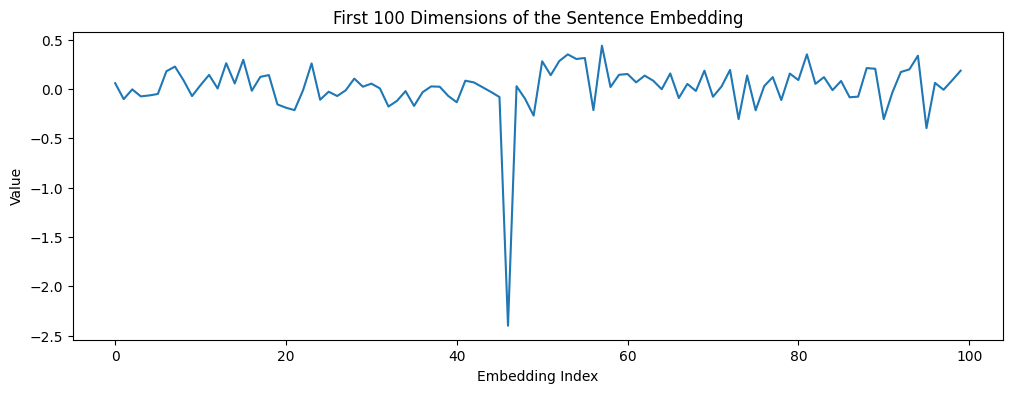

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(sentence_embedding[0][:100])

plt.title("First 100 Dimensions of the Sentence Embedding")

plt.xlabel("Embedding Index")
plt.ylabel("Value")

plt.show()

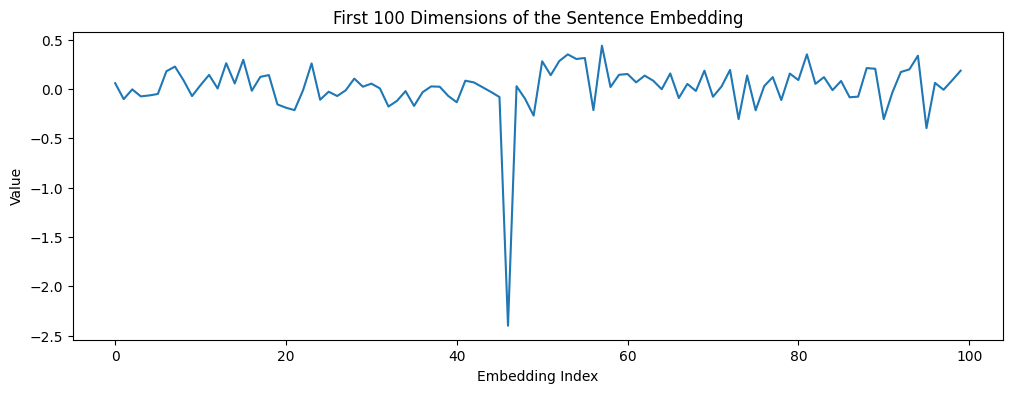

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(sentence_embedding[0][:100])

plt.title("First 100 Dimensions of the Sentence Embedding")

plt.xlabel("Embedding Index")
plt.ylabel("Value")

plt.show()

In [33]:
texts = ["I love NLP.", "Transformers are amazing.", "Machine learning is fun."]

features = []

for sentence in texts:

    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    cls_embedding = outputs.last_hidden_state[0, 0, :].numpy()

    features.append(cls_embedding)

features = np.array(features)

print(features.shape)

(3, 768)


In [34]:
import numpy as np

logits = np.array([2.5, 1.0])

print("Logits:", logits)

Logits: [2.5 1. ]


In [35]:
logits = np.array([2.5, 1.0])

exp_values = np.exp(logits)

softmax_probs = exp_values / exp_values.sum()

print("Exponentials:", np.round(exp_values, 3))
print("Softmax Probabilities:", np.round(softmax_probs, 3))

Exponentials: [12.182  2.718]
Softmax Probabilities: [0.818 0.182]


In [36]:
def softmax(x):
    exp_x = np.exp(x)
    return exp_x / exp_x.sum()


probs = softmax(logits)

print(probs)

[0.81757448 0.18242552]


In [37]:
print("Sum =", probs.sum())

Sum = 1.0


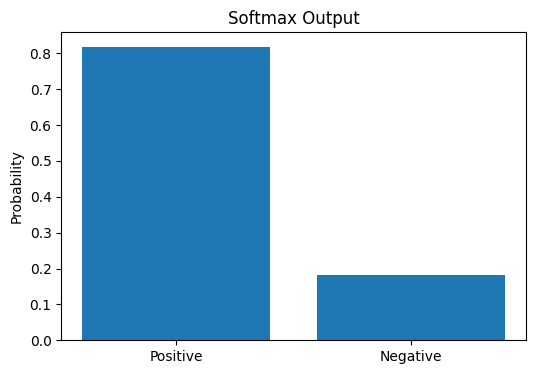

In [38]:
import matplotlib.pyplot as plt

classes = ["Positive", "Negative"]

plt.figure(figsize=(6, 4))
plt.bar(classes, probs)

plt.title("Softmax Output")
plt.ylabel("Probability")

plt.show()

In [39]:
classes = ["Sports", "Politics", "Business", "Technology"]

logits = np.array([2.1, 0.8, 1.5, 3.2])

probs = softmax(logits)

for c, p in zip(classes, probs):
    print(f"{c:12}: {p:.3f}")

Sports      : 0.207
Politics    : 0.056
Business    : 0.114
Technology  : 0.623


In [40]:
good_prediction = 0.90
bad_prediction = 0.10

good_loss = -np.log(good_prediction)
bad_loss = -np.log(bad_prediction)

print("Good Prediction Loss:", round(good_loss, 3))
print("Bad Prediction Loss :", round(bad_loss, 3))

Good Prediction Loss: 0.105
Bad Prediction Loss : 2.303


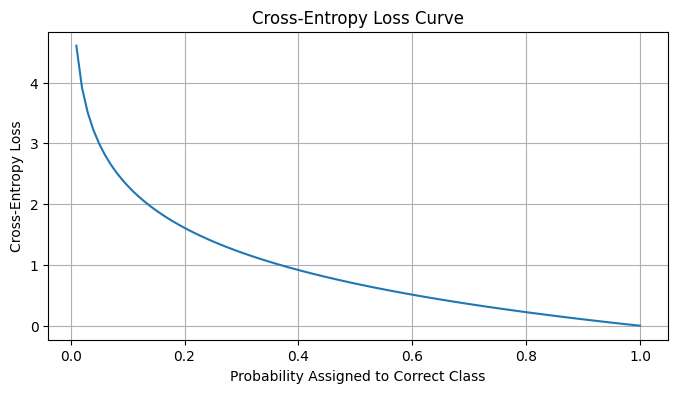

In [41]:
probabilities = np.linspace(0.01, 1.0, 100)

losses = -np.log(probabilities)

plt.figure(figsize=(8, 4))

plt.plot(probabilities, losses)

plt.xlabel("Probability Assigned to Correct Class")

plt.ylabel("Cross-Entropy Loss")

plt.title("Cross-Entropy Loss Curve")

plt.grid(True)

plt.show()

In [42]:
logits = np.array([2.5, 1.0])

probs = softmax(logits)

true_class = 0  # Positive

loss = -np.log(probs[true_class])

print("Probabilities:", probs)
print("Cross-Entropy Loss:", round(loss, 3))

Probabilities: [0.81757448 0.18242552]
Cross-Entropy Loss: 0.201


In [43]:
import torch
import torch.nn as nn

logits = torch.tensor([[2.5, 1.0]])

labels = torch.tensor([0])

criterion = nn.CrossEntropyLoss()

loss = criterion(logits, labels)

print(loss)

tensor(0.2014)


In [44]:
probs = torch.softmax(logits, dim=-1)
loss = criterion(probs, labels)

In [45]:
loss = criterion(logits, labels)

In [46]:
logits = np.array([4.2, 1.3])

probs = softmax(logits)

labels = ["Positive", "Negative"]

for label, prob in zip(labels, probs):
    print(f"{label:10}: {prob*100:.2f}%")

Positive  : 94.78%
Negative  : 5.22%


In [47]:
# while True:

#     raw = input("Enter comma-separated logits (or quit): ")

#     if raw.lower() == "quit":
#         break

#     logits = np.array(list(map(float, raw.split(","))))

#     probs = softmax(logits)

#     print("\nProbabilities:")

#     for i, p in enumerate(probs):
#         print(f"Class {i}: {p:.3f}")

#     print("-" * 40)

In [48]:
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
)

import numpy as np
import evaluate

In [49]:
dataset = load_dataset("emotion")

dataset

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\vinna\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sat Jun 13 12:41:15 2026).


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [50]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

print(tokenizer)

DistilBertTokenizerFast(name_or_path='distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}


In [51]:
sample = dataset["train"][0]["text"]

print(sample)

encoding = tokenizer(sample, truncation=True, padding=True)

print("\nEncoded Output:")
print(encoding)

i didnt feel humiliated

Encoded Output:
{'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}


In [52]:
def tokenize(batch):
    return tokenizer(
        batch["text"], truncation=True, padding="max_length", max_length=64
    )


tokenized_dataset = dataset.map(tokenize, batched=True)

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [53]:
tokenized_dataset = tokenized_dataset.remove_columns(["text"])

tokenized_dataset.set_format("torch")

tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [54]:
num_labels = 6

model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=num_labels
)

print(model)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
          (ffn): FFN(
            (dropout): Dropout(p

In [55]:
accuracy_metric = evaluate.load("accuracy")


def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    return accuracy_metric.compute(predictions=predictions, references=labels)

Using the latest cached version of the module from C:\Users\vinna\.cache\huggingface\modules\evaluate_modules\metrics\evaluate-metric--accuracy\f887c0aab52c2d38e1f8a215681126379eca617f96c447638f751434e8e65b14 (last modified on Sat Jun 13 12:34:48 2026) since it couldn't be found locally at evaluate-metric--accuracy, or remotely on the Hugging Face Hub.


In [56]:
training_args = TrainingArguments(
    output_dir="./results",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=True,
)

In [57]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

In [58]:
small_train = tokenized_dataset["train"].shuffle(seed=42).select(range(200))
small_valid = tokenized_dataset["validation"].shuffle(seed=42).select(range(50))

In [59]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=small_train,
    eval_dataset=small_valid,
    tokenizer=tokenizer,  # or tokenizer=tokenizer for older versions
    compute_metrics=compute_metrics,
)

In [60]:
trainer.train()

  0%|          | 0/26 [00:00<?, ?it/s]

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/4 [00:00<?, ?it/s]

{'eval_loss': 1.6808375120162964, 'eval_accuracy': 0.4, 'eval_runtime': 1.768, 'eval_samples_per_second': 28.28, 'eval_steps_per_second': 2.262, 'epoch': 1.0}


d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/4 [00:00<?, ?it/s]

{'eval_loss': 1.6417850255966187, 'eval_accuracy': 0.42, 'eval_runtime': 2.7101, 'eval_samples_per_second': 18.449, 'eval_steps_per_second': 1.476, 'epoch': 2.0}
{'train_runtime': 65.8549, 'train_samples_per_second': 6.074, 'train_steps_per_second': 0.395, 'train_loss': 1.714525662935697, 'epoch': 2.0}


TrainOutput(global_step=26, training_loss=1.714525662935697, metrics={'train_runtime': 65.8549, 'train_samples_per_second': 6.074, 'train_steps_per_second': 0.395, 'total_flos': 6623842406400.0, 'train_loss': 1.714525662935697, 'epoch': 2.0})

In [61]:
results = trainer.evaluate()

print(results)

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


  0%|          | 0/4 [00:00<?, ?it/s]

{'eval_loss': 1.6417850255966187, 'eval_accuracy': 0.42, 'eval_runtime': 2.1201, 'eval_samples_per_second': 23.584, 'eval_steps_per_second': 1.887, 'epoch': 2.0}


In [62]:
trainer.save_model("fine_tuned_distilbert")

tokenizer.save_pretrained("fine_tuned_distilbert")

print("Model Saved!")

Model Saved!


In [63]:
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="./fine_tuned_distilbert",
    tokenizer="./fine_tuned_distilbert",
)

In [64]:
text = "I am very happy and excited today!"

result = classifier(text)

print(result)

[{'label': 'LABEL_1', 'score': 0.2259191870689392}]


In [65]:
# while True:

#     sentence = input("Enter text (or 'quit'): ")

#     if sentence.lower() == "quit":
#         break

#     prediction = classifier(sentence)

#     print("\nPrediction:")
#     print(prediction)
#     print("-" * 40)

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

documents = [
    "I love this movie",
    "This movie is amazing",
    "I hate this movie",
    "This movie is terrible",
]

labels = [1, 1, 0, 0]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

model = LogisticRegression()

model.fit(X, labels)

LogisticRegression()

In [70]:
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

coef_df = pd.DataFrame({"word": feature_names, "weight": model.coef_[0]})

coef_df.sort_values(by="weight", ascending=False)

,word,weight
3,love,3.465742e-01
0,amazing,3.046784e-01
4,movie,2.629480e-17
6,this,2.629480e-17
2,is,0.000000e+00
5,terrible,-3.046784e-01
1,hate,-3.465742e-01


In [71]:
print("Top Positive Words")
display(coef_df.sort_values(by="weight", ascending=False).head(5))

print("\nTop Negative Words")
display(coef_df.sort_values(by="weight").head(5))

Top Positive Words


,word,weight
3,love,3.465742e-01
0,amazing,3.046784e-01
4,movie,2.629480e-17
6,this,2.629480e-17
2,is,0.000000e+00



Top Negative Words


,word,weight
1,hate,-3.465742e-01
5,terrible,-3.046784e-01
2,is,0.000000e+00
4,movie,2.629480e-17
6,this,2.629480e-17


In [73]:
!pip install shap

  Using cached numpy-2.4.6-cp311-cp311-win_amd64.whl.metadata (6.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp311-cp311-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl.metadata (4.9 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached numpy-2.2.6-cp311-cp311-win_amd64.whl.metadata (60 kB)
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---- ----------------------------------- 61.4/554.9 kB 1.6 MB/s eta 0:00:01
   -------------------------------------- - 532.5/554.9 kB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 554.9/554.9 kB 5.8 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp311-cp311-win_amd64.whl (38.1 MB)
Using cached numba-0.65.1-cp311-cp311-win_amd64.whl (2.7 MB)
Using cached numpy-2.2.6-cp311-cp311-w

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 0.33.0 requires numpy<2.0.0,>=1.17, but you have numpy 2.2.6 which is incompatible.
faiss-cpu 1.8.0.post1 requires numpy<2.0,>=1.0, but you have numpy 2.2.6 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [74]:
import shap

explainer = shap.Explainer(model, X)

shap_values = explainer(X)

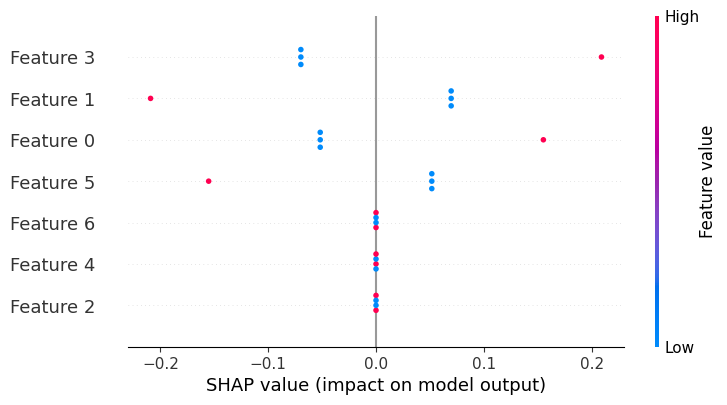

In [76]:
shap.plots.beeswarm(shap_values)

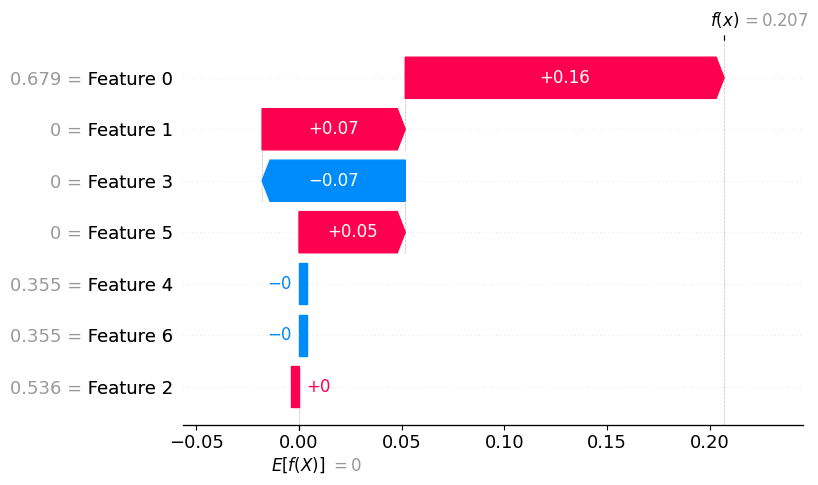

In [77]:
sample = vectorizer.transform(["This movie is amazing"])

sample_shap = explainer(sample)

shap.plots.waterfall(sample_shap[0])

In [83]:
!pip install captum

   ---------------------------------------- 0.0/455.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/455.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/455.2 kB ? eta -:--:--
   --------- ------------------------------ 112.6/455.2 kB 2.2 MB/s eta 0:00:01
   ---------------------------------------- 455.2/455.2 kB 5.7 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [84]:
!pip install captum


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [85]:
classifier = pipeline("sentiment-analysis")

result = classifier("I hated the plot, but the acting was phenomenal.")

print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


[{'label': 'POSITIVE', 'score': 0.9997981190681458}]


In [86]:
from datasets import load_dataset

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [87]:
dataset = load_dataset("emotion")

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

label_names = dataset["train"].features["label"].names

print(label_names)

Using the latest cached version of the dataset since emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at C:\Users\vinna\.cache\huggingface\datasets\emotion\split\0.0.0\cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sat Jun 13 12:41:15 2026).


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [90]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

X_train = tfidf_vectorizer.fit_transform(train_df["text"])

X_test = tfidf_vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test = test_df["label"]


X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 236968 stored elements and shape (16000, 5000)>

In [89]:
tfidf_model = LogisticRegression(max_iter=1000)

tfidf_model.fit(X_train, y_train)

print("TF-IDF Model Ready!")

TF-IDF Model Ready!


In [91]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

transformer_classifier = pipeline("sentiment-analysis")

print("Transformer Ready!")

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision af0f99b (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Transformer Ready!


In [92]:
def predict_tfidf(text):

    x = tfidf_vectorizer.transform([text])

    prediction = tfidf_model.predict(x)[0]

    probabilities = tfidf_model.predict_proba(x)[0]

    return {"prediction": label_names[prediction], "probabilities": probabilities}

In [93]:
def predict_transformer(text):

    output = transformer_classifier(text)[0]

    return {"prediction": output["label"], "confidence": output["score"]}

In [94]:
sentence = "I hated the plot, but the acting was phenomenal."

print("Input:")
print(sentence)

print("\nTF-IDF Model:")
print(predict_tfidf(sentence))

print("\nTransformer Model:")
print(predict_transformer(sentence))

Input:
I hated the plot, but the acting was phenomenal.

TF-IDF Model:
{'prediction': 'anger', 'probabilities': array([0.31386151, 0.05650205, 0.01504706, 0.55011767, 0.04830984,
       0.01616186])}

Transformer Model:
{'prediction': 'POSITIVE', 'confidence': 0.9997981190681458}


In [95]:
sentence = "I hated the plot, but the acting was phenomenal."

print("Input:")
print(sentence)

print("\nTF-IDF Model:")
print(predict_tfidf(sentence))

print("\nTransformer Model:")
print(predict_transformer(sentence))

Input:
I hated the plot, but the acting was phenomenal.

TF-IDF Model:
{'prediction': 'anger', 'probabilities': array([0.31386151, 0.05650205, 0.01504706, 0.55011767, 0.04830984,
       0.01616186])}

Transformer Model:
{'prediction': 'POSITIVE', 'confidence': 0.9997981190681458}


In [96]:
token_ids = tokenizer.convert_tokens_to_ids(tokens)

for token, idx in zip(tokens, token_ids):
    print(f"{token:15} -> {idx}")

i               -> 1045
hated           -> 6283
the             -> 1996
plot            -> 5436
,               -> 1010
but             -> 2021
the             -> 1996
acting          -> 3772
was             -> 2001
phenomena       -> 13352
##l             -> 2140
.               -> 1012


In [97]:
encoding = tokenizer(sentence, return_tensors="pt", padding=True, truncation=True)

print("Input IDs:\n", encoding["input_ids"])

print("\nAttention Mask:\n", encoding["attention_mask"])

Input IDs:
 tensor([[  101,  1045,  6283,  1996,  5436,  1010,  2021,  1996,  3772,  2001,
         13352,  2140,  1012,   102]])

Attention Mask:
 tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


In [98]:
tfidf_vector = tfidf_vectorizer.transform([sentence])

feature_names = tfidf_vectorizer.get_feature_names_out()

values = tfidf_vector.toarray()[0]

tfidf_df = pd.DataFrame({"word": feature_names, "score": values})

tfidf_df = tfidf_df[tfidf_df["score"] > 0]

tfidf_df.sort_values(by="score", ascending=False)

,word,score
42,acting,0.579407
3236,plot,0.566798
1925,hated,0.418117
4433,the,0.278685
4788,was,0.218669
551,but,0.206701


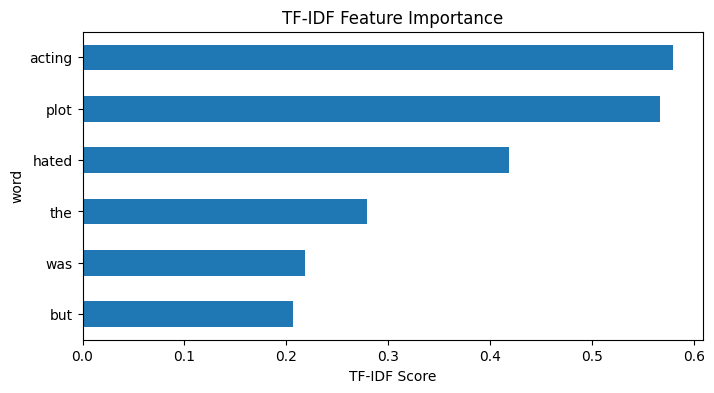

In [99]:
tfidf_df.sort_values(by="score").plot(
    x="word", y="score", kind="barh", figsize=(8, 4), legend=False
)

plt.title("TF-IDF Feature Importance")

plt.xlabel("TF-IDF Score")

plt.show()

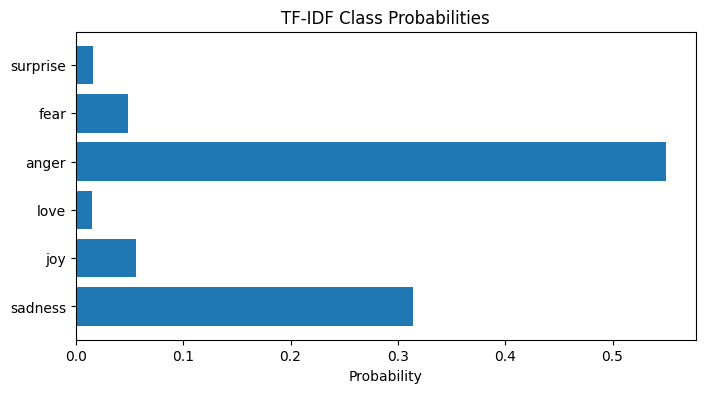

In [100]:
result = predict_tfidf(sentence)

probs = result["probabilities"]

plt.figure(figsize=(8, 4))

plt.barh(label_names, probs)

plt.xlabel("Probability")

plt.title("TF-IDF Class Probabilities")

plt.show()

In [101]:
coef_df = pd.DataFrame(
    {"word": tfidf_vectorizer.get_feature_names_out(), "weight": tfidf_model.coef_[0]}
)

top_positive = coef_df.sort_values(by="weight", ascending=False).head(10)

top_negative = coef_df.sort_values(by="weight").head(10)

print("Top Positive Features")
display(top_positive)

print("\nTop Negative Features")
display(top_negative)

Top Positive Features


,word,weight
2475,lethargic,4.650695
2688,melancholy,4.571299
3411,punished,4.340093
539,burdened,4.322461
4679,unwelcome,4.229295
301,awkward,4.210913
2754,missed,4.201628
1176,disturbed,4.139489
4582,troubled,4.130766
4647,unfortunate,4.130250



Top Negative Features


,word,weight
4218,strange,-2.888070
4332,sweet,-2.728423
4305,supporting,-2.550496
4830,weird,-2.527706
19,accepted,-2.500853
4533,tortured,-2.409754
3050,overwhelmed,-2.399712
93,agitated,-2.376931
127,amazing,-2.344243
3112,passionate,-2.282941


In [102]:
while True:

    text = input("\nEnter text (or quit): ")

    if text.lower() == "quit":
        break

    tfidf_result = predict_tfidf(text)

    transformer_result = predict_transformer(text)

    print("\n==========================")
    print("INPUT:")
    print(text)

    print("\nTF-IDF Prediction:")
    print(tfidf_result["prediction"])

    print("\nTransformer Prediction:")
    print(transformer_result["prediction"])

    print("Confidence:", round(transformer_result["confidence"] * 100, 2), "%")

    print("==========================")


INPUT:
vinay is radinat soul

TF-IDF Prediction:
joy

Transformer Prediction:
POSITIVE
Confidence: 98.11 %

INPUT:


TF-IDF Prediction:
joy

Transformer Prediction:
POSITIVE
Confidence: 74.81 %

INPUT:


TF-IDF Prediction:
joy

Transformer Prediction:
POSITIVE
Confidence: 74.81 %


KeyboardInterrupt: Interrupted by user

In [ ]:
while True:

    text = input("\nEnter text (or quit): ")

    if text.lower() == "quit":
        break

    tfidf_result = predict_tfidf(text)

    transformer_result = predict_transformer(text)

    print("\n==========================")
    print("INPUT:")
    print(text)

    print("\nTF-IDF Prediction:")
    print(tfidf_result["prediction"])

    print("\nTransformer Prediction:")
    print(transformer_result["prediction"])

    print("Confidence:", round(transformer_result["confidence"] * 100, 2), "%")

    print("==========================")

In [103]:
sentence = "I hated the plot, but the acting was phenomenal."

importance = {"hated": -0.8, "plot": -0.3, "acting": 0.4, "phenomenal": 0.9}

for word in sentence.split():

    clean_word = word.lower().replace(",", "").replace(".", "")

    if clean_word in importance:

        score = importance[clean_word]

        if score > 0:
            print(f"🟢 {word} ({score:.2f})")
        else:
            print(f"🔴 {word} ({score:.2f})")
    else:
        print(f"⚪ {word}")

⚪ I
🔴 hated (-0.80)
⚪ the
🔴 plot, (-0.30)
⚪ but
⚪ the
🟢 acting (0.40)
⚪ was
🟢 phenomenal. (0.90)


In [104]:
def visualize_prediction(text):

    print("=" * 60)
    print("INPUT TEXT:")
    print(text)

    print("\nTokenized:")
    print(tokenizer.tokenize(text))

    tfidf_result = predict_tfidf(text)

    print("\nTF-IDF Prediction:")
    print(tfidf_result["prediction"])

    transformer_result = predict_transformer(text)

    print("\nTransformer Prediction:")
    print(transformer_result)

    print("=" * 60)

In [105]:
visualize_prediction("I absolutely love learning Transformers!")

INPUT TEXT:
I absolutely love learning Transformers!

Tokenized:
['i', 'absolutely', 'love', 'learning', 'transformers', '!']

TF-IDF Prediction:
joy

Transformer Prediction:
{'prediction': 'POSITIVE', 'confidence': 0.9997283816337585}
